# Compare Old vs New Training Runs

Compares `train_metrics_20260108_2116.jsonl` (old run, pre-GQA-refactor
architecture, B=32, 24 heads MHA) against `train_metrics_20260623_1803.jsonl` (new run,
exp-044-style compound config: parallel block, n_head=16, n_kv_heads=4 GQA,
rope_base=50000, B=32).

Re-run this notebook any time to pick up the latest lines from the new
run's still-growing log file.

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# --- Config: paths + batch size used by each run (T is 1024 for both) ---
OLD_METRICS_PATH = "../../logs/train_metrics_20260108_2116.jsonl"
# OLD_METRICS_PATH = "../../logs/train_metrics_20260623_2019.jsonl"
NEW_METRICS_PATH = "../../logs/train_metrics_20260624_1302.jsonl"

OLD_B = 32  # batch size in effect during the old run
NEW_B = 32  # batch size in effect during the new run (lowered to fit H100 80GB)
T = 1024

OLD_LABEL = "Old run (pre-refactor)"
NEW_LABEL = "New run (PaLM + GQA refactor)"
OLD_COLOR = "tab:grey"
NEW_COLOR = "tab:blue"


In [2]:
def load_metrics(path, batch_size):
    with open(path, "r") as f:
        records = [json.loads(line) for line in f]

    df = pd.DataFrame(records)
    df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed")
    df["elapsed_hours"] = (
        df["timestamp"] - df["timestamp"].iloc[0]
    ).dt.total_seconds() / 3600
    df["tokens_seen_b"] = (df["step"] * batch_size * T) / 1e9  # billions of tokens
    return df


df_old = load_metrics(OLD_METRICS_PATH, OLD_B)
df_new = load_metrics(NEW_METRICS_PATH, NEW_B)

print(f"Old run: {len(df_old)} log rows, {df_old['tokens_seen_b'].max():.2f}B tokens, "
      f"{df_old['elapsed_hours'].max():.1f}h elapsed")
print(f"New run: {len(df_new)} log rows, {df_new['tokens_seen_b'].max():.2f}B tokens, "
      f"{df_new['elapsed_hours'].max():.1f}h elapsed")


Old run: 116052 log rows, 44.24B tokens, 214.9h elapsed
New run: 105736 log rows, 40.30B tokens, 131.5h elapsed


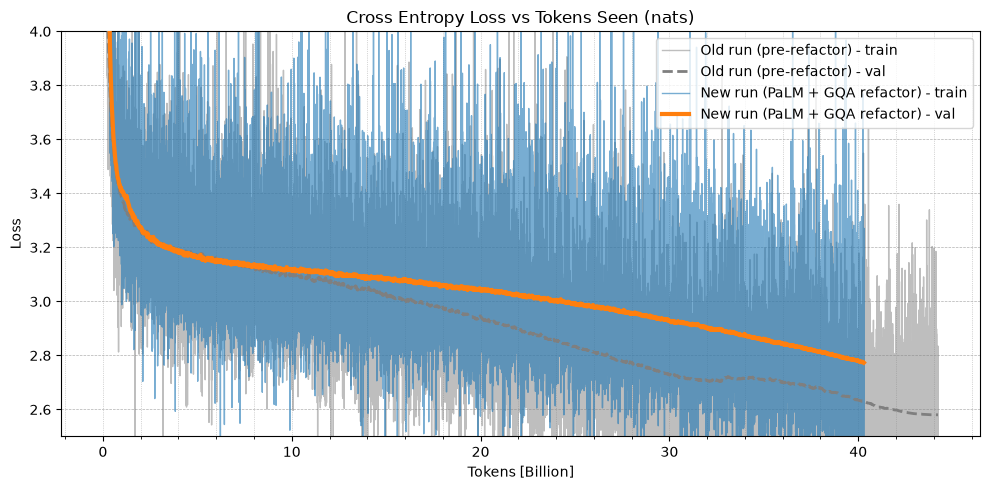

In [3]:
# --- Loss comparison: train + val loss vs tokens seen ---

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

ax.plot(df_old["tokens_seen_b"], df_old["train_loss"], color=OLD_COLOR,
        alpha=0.5, linewidth=1, label=f"{OLD_LABEL} - train")
ax.plot(df_old["tokens_seen_b"][df_old["val_loss"].notna()],
        df_old["val_loss"][df_old["val_loss"].notna()], color=OLD_COLOR,
        linestyle="--", linewidth=2, label=f"{OLD_LABEL} - val", zorder=4)

ax.plot(df_new["tokens_seen_b"], df_new["train_loss"], color=NEW_COLOR,
        alpha=0.6, linewidth=1, label=f"{NEW_LABEL} - train")
ax.plot(df_new["tokens_seen_b"][df_new["val_loss"].notna()],
        df_new["val_loss"][df_new["val_loss"].notna()], color="tab:orange",
        linewidth=3, label=f"{NEW_LABEL} - val", zorder=5)

ax.legend()
ax.set_xlabel("Tokens [Billion]")
ax.set_ylabel("Loss")
ax.set_title("Cross Entropy Loss vs Tokens Seen (nats)")
ax.yaxis.grid(True, which="both", linestyle="--", linewidth=0.5)
ax.xaxis.set_major_locator(mticker.AutoLocator())
ax.xaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.xaxis.grid(True, which="both", linestyle=":", linewidth=0.5)
ax.set_ylim(bottom=2.5, top=4)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


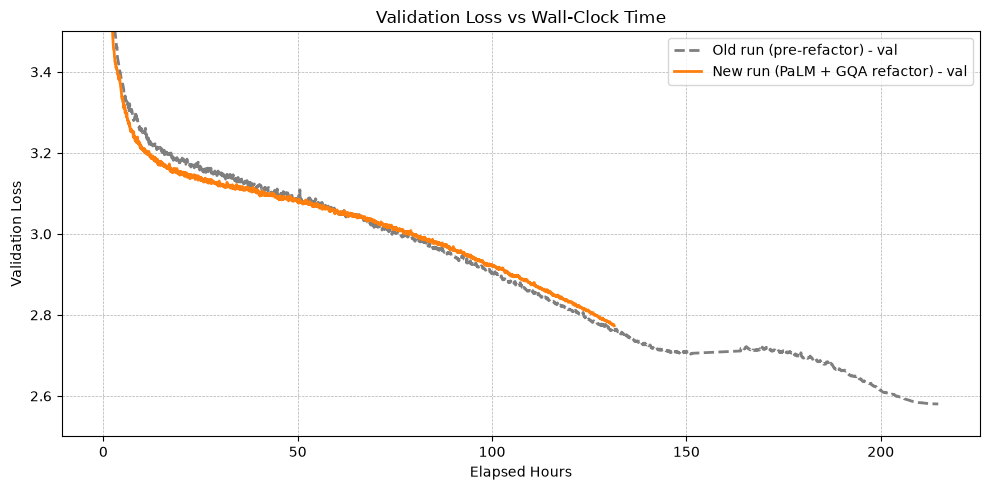

In [4]:
# --- Loss comparison vs wall-clock hours (shows throughput differences too) ---

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")

ax.plot(df_old["elapsed_hours"][df_old["val_loss"].notna()],
        df_old["val_loss"][df_old["val_loss"].notna()], color=OLD_COLOR,
        linestyle="--", linewidth=2, label=f"{OLD_LABEL} - val")
ax.plot(df_new["elapsed_hours"][df_new["val_loss"].notna()],
        df_new["val_loss"][df_new["val_loss"].notna()], color="tab:orange",
        linewidth=2, label=f"{NEW_LABEL} - val")

ax.legend()
ax.set_xlabel("Elapsed Hours")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss vs Wall-Clock Time")
ax.grid(True, linestyle="--", linewidth=0.5)
ax.set_ylim(bottom=2.5, top=3.5)
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()


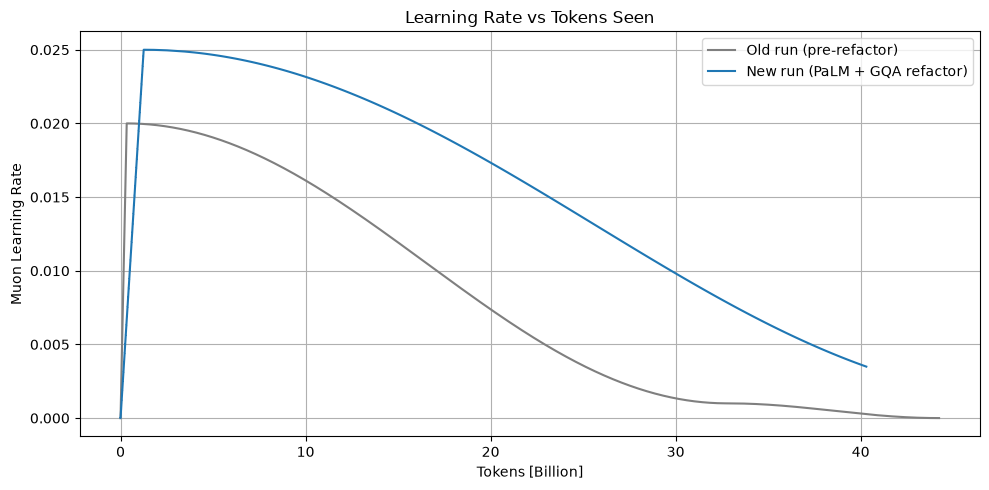

In [5]:
# --- Learning rate comparison ---

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.plot(df_old["tokens_seen_b"], df_old["muon_lr"], color=OLD_COLOR, label=OLD_LABEL)
ax.plot(df_new["tokens_seen_b"], df_new["muon_lr"], color=NEW_COLOR, label=NEW_LABEL)
ax.set_xlabel("Tokens [Billion]")
ax.set_ylabel("Muon Learning Rate")
ax.set_title("Learning Rate vs Tokens Seen")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


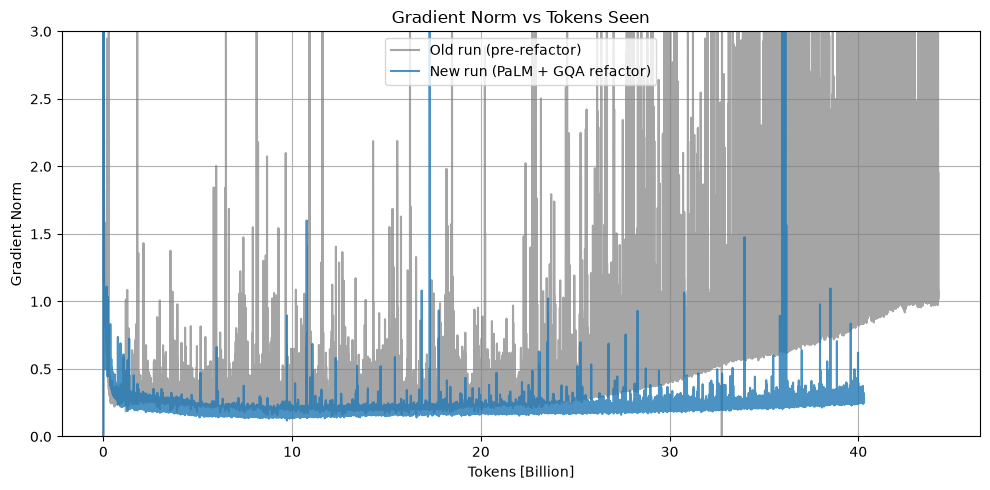

In [6]:
# --- Gradient norm comparison ---

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.plot(df_old["tokens_seen_b"], df_old["norm"], color=OLD_COLOR, alpha=0.7, label=OLD_LABEL)
ax.plot(df_new["tokens_seen_b"], df_new["norm"], color=NEW_COLOR, alpha=0.8, label=NEW_LABEL)
ax.set_xlabel("Tokens [Billion]")
ax.set_ylabel("Gradient Norm")
ax.set_title("Gradient Norm vs Tokens Seen")
ax.set_ylim(bottom=0, top=3)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


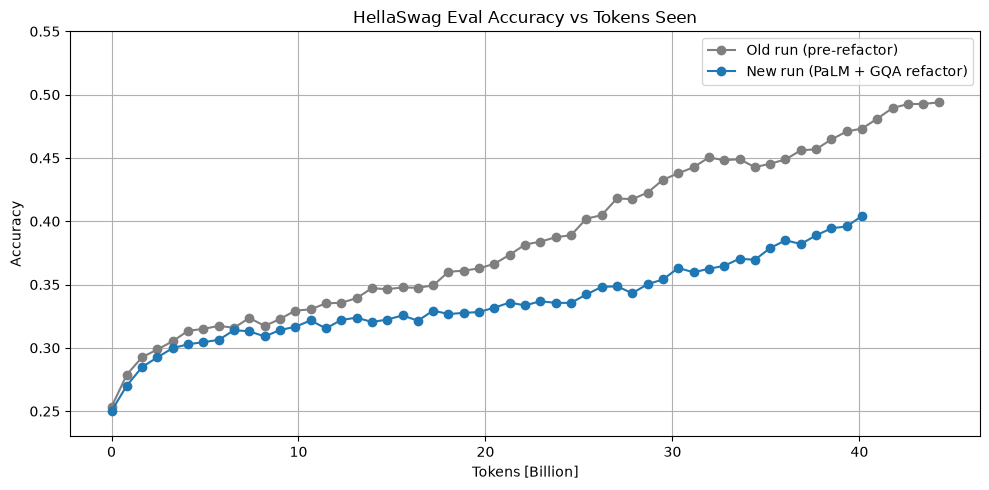

In [7]:
# --- HellaSwag accuracy comparison ---

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.plot(df_old["tokens_seen_b"][df_old["hellaswag_acc"].notna()],
        df_old["hellaswag_acc"][df_old["hellaswag_acc"].notna()],
        color=OLD_COLOR, marker="o", label=OLD_LABEL)
ax.plot(df_new["tokens_seen_b"][df_new["hellaswag_acc"].notna()],
        df_new["hellaswag_acc"][df_new["hellaswag_acc"].notna()],
        color=NEW_COLOR, marker="o", label=NEW_LABEL)
ax.set_xlabel("Tokens [Billion]")
ax.set_ylabel("Accuracy")
ax.set_title("HellaSwag Eval Accuracy vs Tokens Seen")
ax.set_ylim(bottom=0.23, top=0.55)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
